In [22]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from skimage.feature import hog

print("Libraries Installed!")

Libraries Installed!


In [23]:
dataset_path = "leapGestRecog"

print("Dataset Path:", dataset_path)

Dataset Path: leapGestRecog


In [24]:
print(os.getcwd())

c:\Users\Dhanu Sree\OneDrive\Desktop\Skill Craft Internship\SCT_ML_04\Hand-Gesture-Recognition


In [25]:
print(os.listdir())

['app.py', 'hand_gesture_model.pkl', 'hand_gesture_recognition.ipynb', 'leapGestRecog', 'README.md', 'requirements.txt', 'scaler.pkl']


In [26]:
gesture_counts = {}

for person in os.listdir(dataset_path):

    person_path = os.path.join(dataset_path, person)

    for gesture in os.listdir(person_path):

        gesture_path = os.path.join(
            person_path,
            gesture
        )

        count = len(os.listdir(gesture_path))

        gesture_counts[gesture] = (
            gesture_counts.get(gesture, 0)
            + count
        )

df = pd.DataFrame(
    gesture_counts.items(),
    columns=["Gesture", "Count"]
)

df

,Gesture,Count
0,01_palm,200
1,02_l,200
2,03_fist,7


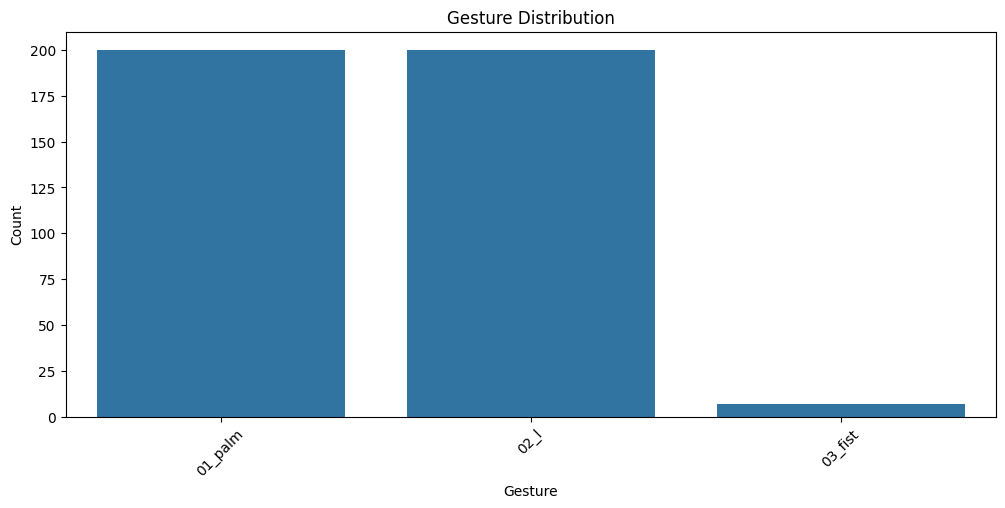

In [27]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=df["Gesture"],
    y=df["Count"]
)

plt.xticks(rotation=45)

plt.title("Gesture Distribution")

plt.show()

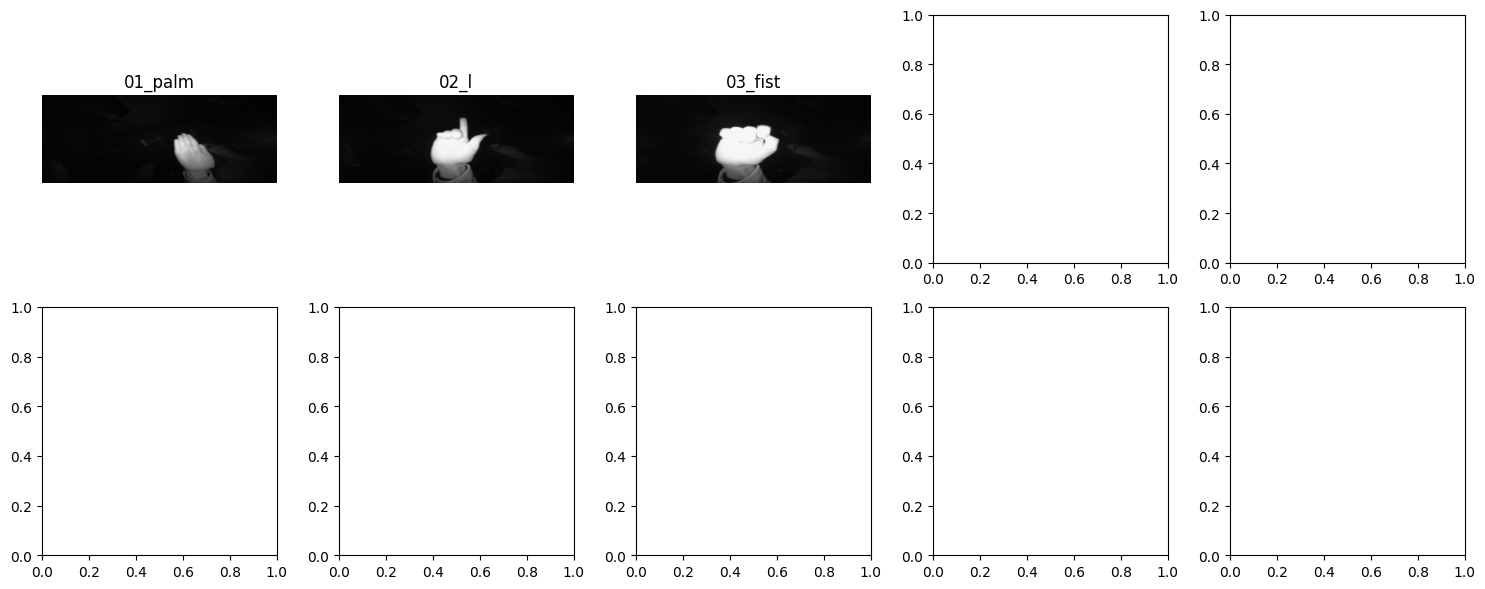

In [28]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(15,6)
)

i = 0

for gesture in gesture_counts.keys():

    person = os.listdir(dataset_path)[0]

    img_folder = os.path.join(
        dataset_path,
        person,
        gesture
    )

    img_name = os.listdir(img_folder)[0]

    img = cv2.imread(
        os.path.join(img_folder, img_name)
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    axes[i//5, i%5].imshow(img)

    axes[i//5, i%5].set_title(gesture)

    axes[i//5, i%5].axis("off")

    i += 1

plt.tight_layout()

plt.show()

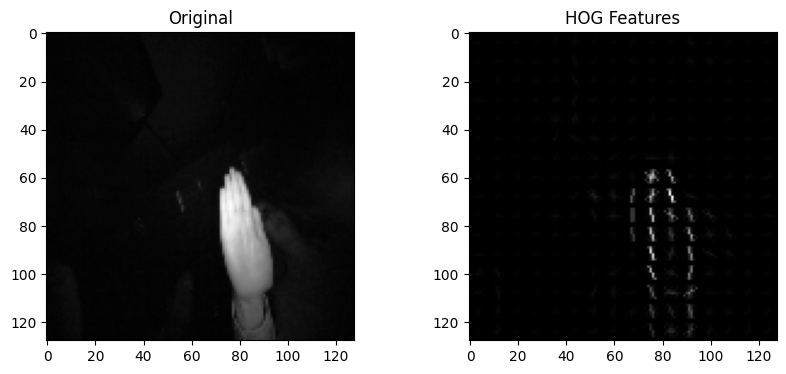

In [29]:
sample = cv2.imread(
    os.path.join(
        dataset_path,
        os.listdir(dataset_path)[0],
        list(gesture_counts.keys())[0],
        os.listdir(
            os.path.join(
                dataset_path,
                os.listdir(dataset_path)[0],
                list(gesture_counts.keys())[0]
            )
        )[0]
    ),
    cv2.IMREAD_GRAYSCALE
)

sample = cv2.resize(sample, (128,128))

fd, hog_image = hog(
    sample,
    visualize=True
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Features")

plt.show()

In [30]:
X = []
y = []

for person in os.listdir(dataset_path):

    person_path = os.path.join(
        dataset_path,
        person
    )

    for gesture in os.listdir(person_path):

        gesture_path = os.path.join(
            person_path,
            gesture
        )

        for image in os.listdir(gesture_path):

            img_path = os.path.join(
                gesture_path,
                image
            )

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            img = cv2.resize(
                img,
                (128,128)
            )

            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2)
            )

            X.append(features)

            y.append(gesture)

print("Total Samples:", len(X))
print("Feature Length:", len(X[0]))

Total Samples: 407
Feature Length: 8100


In [31]:
X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (325, 8100)
Testing Data Shape: (82, 8100)


In [32]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


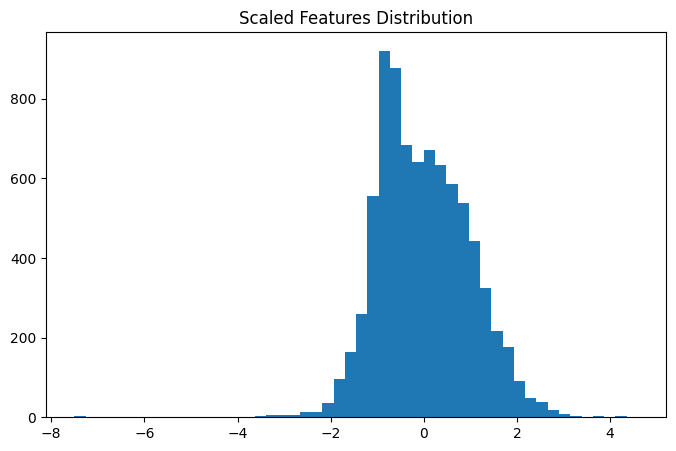

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    X_train[0],
    bins=50
)

plt.title("Scaled Features Distribution")

plt.show()

In [35]:
svm = SVC(
    kernel="rbf",
    probability=True
)

svm.fit(
    X_train,
    y_train
)

print("Training Completed!")

Training Completed!


In [ ]:
y_pred = svm.predict(X_test)

print("Predictions Generated Successfully!")
comparison_df = pd.DataFrame({
    "Actual Label": y_test[:10],
    "Predicted Label": y_pred[:10]
})

comparison_df
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):

    ax.imshow(leapGestRecog\00\01_palm\frame_00_01_0001.png[i], cmap="gray")

    ax.set_title(
        f"Actual: {y_test[i]}\nPred: {y_pred[i]}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle("Gesture Prediction Results", fontsize=16)

plt.tight_layout()

plt.show()

Predictions Generated Successfully!


,Actual Label,Predicted Label
0,01_palm,01_palm
1,01_palm,01_palm
2,02_l,02_l
3,01_palm,01_palm
4,03_fist,02_l
5,01_palm,01_palm
6,01_palm,01_palm
7,02_l,02_l
8,02_l,02_l
9,01_palm,01_palm


In [38]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Model Accuracy: {accuracy*100:.2f}%"
)

Model Accuracy: 97.56%


In [39]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     01_palm       1.00      1.00      1.00        40
        02_l       0.95      1.00      0.98        40
     03_fist       0.00      0.00      0.00         2

    accuracy                           0.98        82
   macro avg       0.65      0.67      0.66        82
weighted avg       0.95      0.98      0.96        82



c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dhanu Sree\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


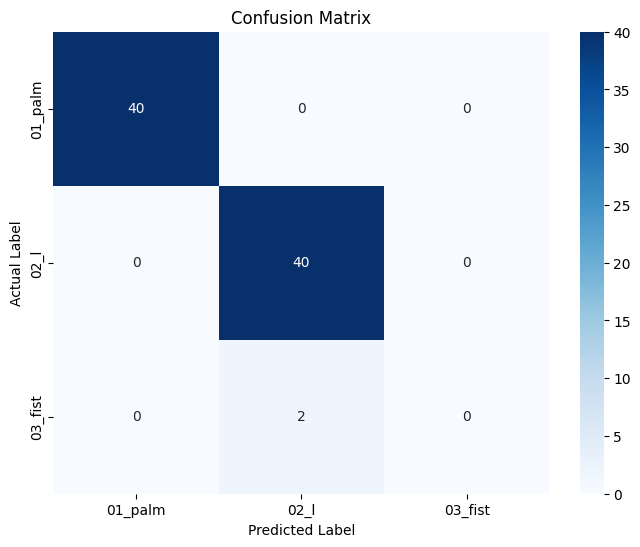

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [41]:
print("="*40)

print(
    f"Final Model Accuracy: {accuracy*100:.2f}%"
)

print("="*40)

Final Model Accuracy: 97.56%


In [42]:
joblib.dump(
    svm,
    "gesture_svm.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model and Scaler Saved Successfully!")

Model and Scaler Saved Successfully!


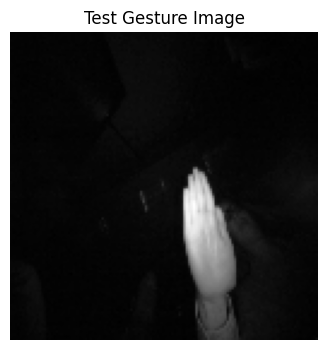

Predicted Gesture: 01_palm
Confidence Score: 99.16%


In [45]:
import os
import cv2
import numpy as np
from skimage.feature import hog

# Replace with your actual image path
img_path = r"leapGestRecog\00\01_palm\frame_00_01_0001.png"

# Check if image exists
if not os.path.exists(img_path):
    print(f"Image not found: {img_path}")

else:
    sample_img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    sample_img = cv2.resize(
        sample_img,
        (128, 128)
    )

    features = hog(
        sample_img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    features = scaler.transform([features])

    prediction = svm.predict(features)[0]

    confidence = (
        np.max(
            svm.predict_proba(features)
        ) * 100
    )

    plt.figure(figsize=(4,4))
    plt.imshow(sample_img, cmap="gray")
    plt.title("Test Gesture Image")
    plt.axis("off")
    plt.show()

    print("Predicted Gesture:", prediction)
    print(f"Confidence Score: {confidence:.2f}%")